In [1]:
import sys
sys.path.append("/home/mariacst/exoplanets/exoplanets/cluster/")

import derivatives
import imp
imp.reload(derivatives)
import numpy as np

from astropy.constants import G, sigma_sb, R_jup, c, M_sun
import astropy.units as u

import matplotlib.pyplot as plt
from utils import T_DM

from scipy.misc import derivative

In [2]:
path = "/home/mariacst/exoplanets/running/data/"

masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)           
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)             

from scipy.interpolate import interp1d
from scipy.interpolate import griddata

a_interp = interp1d(masses, a)                                                   
b_interp = interp1d(masses, b)                                                    
c_interp = interp1d(ages, c)
                                  
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2] 

# Second derivative temperature with respect to mass

\begin{equation}
    \frac{\partial^2T}{\partial M^2}
\end{equation}

<p style="color:red;">
FIXME: some issues with xi and griddata when vectorising. See below   
</p>

**Second derivative TDM wrt mass**

In [6]:
imp.reload(derivatives)
from derivatives import dderivativeTDM_wrt_M, dderivativeT_wrt_M

In [7]:
path = "/home/mariacst/exoplanets/running/data/"

masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)           
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)             

from scipy.interpolate import interp1d
from scipy.interpolate import griddata

a_interp = interp1d(masses, a)                                                   
b_interp = interp1d(masses, b)                                                    
c_interp = interp1d(ages, c)
                                  
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2] 

In [55]:
r=0.1; f=1.; params=[1., 20., 0.42]; v=100.; 
M=0.035; A=1.193777

masses = np.linspace(0.02, 0.045, 20)

In [56]:
_sigma_sb               = sigma_sb.value                                                      
_G                      = G.value 
conversion_into_K_vs_kg = 1.60217e-7
conv_Msun_to_kg         = 1.98841e+30
conversion_into_w       = 0.16021766

from utils import gNFW_rho

def derivativeTDM_wrt_M(M, r, f, params, v, R=R_jup.value, Rsun=8.178, epsilon=1):                                                
    """                                                                            
    Return (analytical) derivative of DM temperature wrt mass @                    
    (f, gamma, rs, rho0, r, M, R) [K/Msun]                                         
                                                                                   
    Input                                                                          
    -----                                                                          
        r      : Galactocentric distance [kpc]                                     
        params : DM parameters [f, gamma, rs]                                      
        M      : exoplanet mass [Msun]                                             
    """                                                                            
    # escape velocity                                                              
    vesc   = np.sqrt(2*_G*M*conv_Msun_to_kg/R)*1e-3 # km/s                         
    if v:                                                                          
        _vD = v                                                                    
        #print(_vD, "here i am")                                                   
    else:                                                                          
        _vD    = np.sqrt(3/2.)*vc(Rsun, r, params) # km/s                          
                                                                                   
    _vDM   =  np.sqrt(8./(3*np.pi))*_vD # km/s                                     
    _rhoDM = gNFW_rho(Rsun, r, params) # GeV/cm3                                   
                                                                                   
    # DM temperature^-3 [1/K^3]                                                    
    T_DM3 = np.power((f*_rhoDM*_vDM*(1+3./2.*np.power(vesc/_vD, 2))*               
                     conversion_into_w)/(4*_sigma_sb*epsilon), -3./4.)             
    # return                                                                       
    return (T_DM3*3./16.*np.sqrt(8./3./np.pi)*f/_sigma_sb/                         
            epsilon*_rhoDM*_G/_vD/R*                                               
            conversion_into_K_vs_kg*conv_Msun_to_kg                                
           )                                                                       

dd_num  = []
dd_ana  = []
TDM_ana = []
for M in masses:

    TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    TDM_ana.append(TDM)

    dd_num.append(derivative(derivativeTDM_wrt_M, M, args=(r, f, params, v), dx=1e-5, order=3))
    
    dervTDM_M = derivativeTDM_wrt_M(M, r, f, params, v)
    print(dervTDM_M)
    
    dd_ana.append(dderivativeTDM_wrt_M(TDM, dervTDM_M))

5511.854151040934
5274.786052953978
5060.220630189869
4864.973875339487
4686.446092518698
4522.492404072469
4371.326449641882
4231.44771577877
4101.585967523751
3980.6582429118603
3867.73520226169
3762.0145304617818
3662.7997178843616
3569.482986442014
3481.531441421219
3398.475756401866
3319.90086409167
3245.4382481045513
3174.759521858809
3107.571049409754


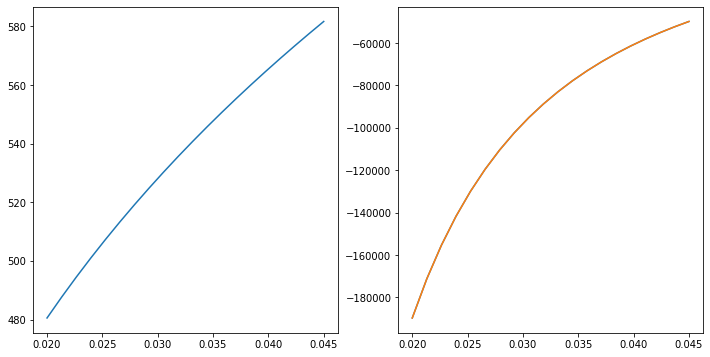

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(masses, TDM_ana)
ax[1].plot(masses, dd_num, label="num")
ax[1].plot(masses, dd_ana, label="ana")

In [58]:
imp.reload(derivatives)
from derivatives import derivativeTDM_wrt_M, dderivativeT_wrt_M
from utils import T_DM

def derivativeT_wrt_M(M, r, A, f, params, v, c):
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    Ttot = np.power(Tint**4+TDM**4, 0.25)
    
    return (Tint/Ttot)**3*c(A) +  (TDM/Ttot)**3*derivativeTDM_wrt_M(r, f, params, M, v)

dd_num = []; dd_ana = []

for M in masses:
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    Ttot = np.power(Tint**4+TDM**4, 0.25)
        
    dd_num.append(derivative(derivativeT_wrt_M, M, args=(r, A, f, params, v, c_interp), dx=1e-5))    

FIXME: some issues in here

In [59]:
#xi   = np.transpose(np.asarray([A, masses[:]]))
#print(masses.shape, xi.shape, points.shape, values.shape)
#print(xi)
#Tint = griddata(points, values, xi)[0]

Tint = []
for M in masses:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])

Tint = np.asarray(Tint)

In [61]:
TDM  = T_DM(r, M=masses*M_sun.value, f=f, params=params, v=v)
Ttot = np.power(Tint**4+TDM**4, 0.25)

dd_ana = dderivativeT_wrt_M(r, masses, A, Tint, TDM, Ttot, c_interp, f, params, v)

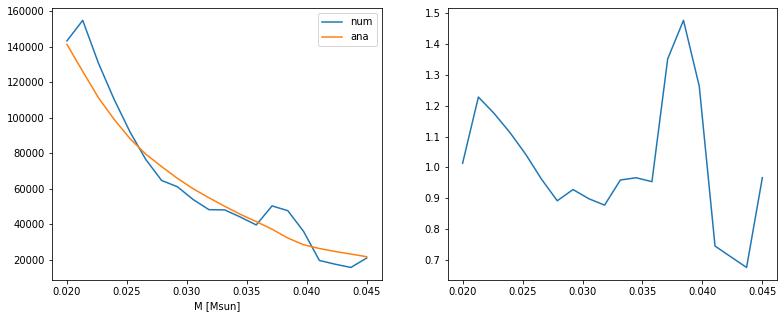

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(masses, dd_num, label="num")
ax[0].plot(masses, dd_ana, label="ana"); ax[0].legend()
ax[0].set_xlabel("M [Msun]")
dd_num = np.asarray(dd_num); dd_ana = np.asarray(dd_ana)
ax[1].plot(masses, dd_num/dd_ana)

# Second derivative temperature with respect to age

In [65]:
import derivatives
import imp
imp.reload(derivatives)
import numpy as np

from derivatives import dderivativeT_wrt_A, dderivativeTint_wrt_A

In [66]:
r=0.1; f=1.; params=[1., 20., 0.42]; v=100.; 
M=0.035; 
ages=np.linspace(1, 10, 30)
M = 0.03

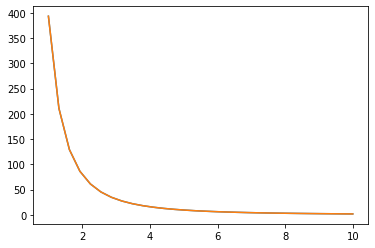

In [19]:
from utils import T_DM

def derivativeTintana_wrt_A(A, M, a, b, Tint, Ttot):                                           
    """                                                                            
    Return (analytical) derivative of interinsic temperature wrt age [K/Gyr]    
    (ATMO temperatures are fitted by a/A^b)                                        
                                                                                   
    Input                                                                          
    -----                                                                          
        M : mass [Msun]                                                            
        A : age [Gyr]                                                              
        a : =f(M) - interpolation function                                         
        b : =f(M) - interpolation function                                         
    """                                                                            
    return (-a(M)*b(M)*np.power(A, -b(M)-1)) 

dd_num = []
dd_ana = []

TDM = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)

for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    _Tint = griddata(points, values, xi)[0]
    Ttot  = np.power(_Tint**4 + TDM**4, 0.25)
    
    dd_ana.append(derivative(derivativeTintana_wrt_A, A, args=(M, a_interp, b_interp, _Tint, Ttot), dx=1e-5))    
    dd_num.append(dderivativeTint_wrt_A(M, A, a_interp, b_interp))
    
fig, ax = plt.subplots()
ax.plot(ages, dd_ana)
ax.plot(ages, dd_num)

In [67]:
from utils import T_DM

def derivativeTintana_wrt_A(A, M, a, b, Tint, Ttot):                                           
    """                                                                            
    Return (analytical) derivative of interinsic temperature wrt age [K/Gyr]    
    (ATMO temperatures are fitted by a/A^b)                                        
                                                                                   
    Input                                                                          
    -----                                                                          
        M : mass [Msun]                                                            
        A : age [Gyr]                                                              
        a : =f(M) - interpolation function                                         
        b : =f(M) - interpolation function                                         
    """                                                                            
    return (Tint/Ttot)**3*(-a(M)*b(M)*np.power(A, -b(M)-1)) 

dd_num = []

TDM = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)

for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    _Tint = griddata(points, values, xi)[0]
    Ttot  = np.power(_Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(derivativeTintana_wrt_A, A, args=(M, a_interp, b_interp, _Tint, Ttot), dx=1e-5))

In [70]:
Tint = []
for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])

Tint = np.asarray(Tint)
Ttot = np.power(Tint**4 + TDM**4, 0.25)

dd_ana = dderivativeT_wrt_A(M, ages, Tint, Ttot, a_interp, b_interp)

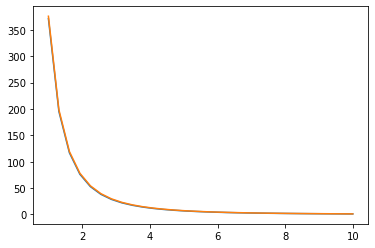

In [71]:
fig, ax = plt.subplots()
ax.plot(ages, dd_ana)
ax.plot(ages, dd_num)

# Second derivative temperature with respect to Galactocentric distance

In [4]:
from derivatives import dderivativeT_wrt_r, dderivativeTDM_wrt_r, derivativeTDM_wrt_r

In [5]:
radius=np.linspace(0.1, 1, 20); f=1.; params=[1., 20., 0.42]; v=100.; 
M=0.023; A=5.4

xi   = np.transpose(np.asarray([A, M]))
Tint = griddata(points, values, xi)[0]

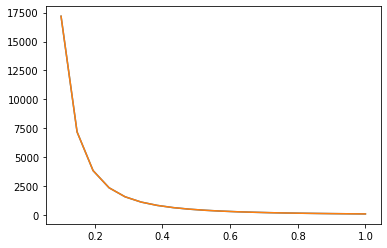

In [29]:
dd_ana = []
dd_num = []

for r in radius:
    TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(derivativeTDM_wrt_r, r, args=(f, params, M, v), dx=1e-5))
    dd_ana.append(dderivativeTDM_wrt_r(r, f, params, M, v, TDM))
    
fig, ax = plt.subplots()
ax.plot(radius, dd_ana)
ax.plot(radius, dd_num)

In [6]:
#dd_ana = []
dd_num = []

from astropy.constants import sigma_sb, G
from utils import gNFW_rho
_sigma_sb = sigma_sb.value                                                      
_G        = G.value                                                             
conversion_into_K_vs_kg = 1.60217e-7                                            
conversion_into_w       = 0.16021766                                            
conv_Msun_to_kg         = 1.98841e+30

def derivativeTDM_wrt_r(r, f, params, M, v, TDM, Ttot, R=R_jup.value, Rsun=8.178,          
                        epsilon=1):                                             
    """                                                                         
    Return (analytical) derivative of DM temperature wrt r @                    
    (f, gamma, rs, rho0, r, M, R) [K/kpc]                                       
                                                                                
    Assumption: DM velocity and velocity dispersion constant!                   
                                                                                
    Input                                                                       
    -----                                                                       
        r      : Galactocentric distance [kpc]                                  
        params : DM parameters [f, gamma, rs]                                   
        M      : exoplanet mass [Msun]                                          
    """                                                                         
    # escape velocity                                                           
    vesc   = np.sqrt(2*_G*M*conv_Msun_to_kg/R)*1e-3 # km/s                      
    if v:                                                                       
        _vD = v                                                                 
        #print(_vD, "here i am")                                                
    else:                                                                       
        _vD    = np.sqrt(3/2.)*vc(Rsun, r, params) # km/s                       
                                                                                
    _vDM   =  np.sqrt(8./(3*np.pi))*_vD # km/s                                  
    _rhoDM = gNFW_rho(Rsun, r, params) # GeV/cm3                                
                                                                                
    # DM temperature [K]                                                        
    T_DM = np.power((f*_rhoDM*_vDM*(1+3./2.*np.power(vesc/_vD, 2))*             
                     conversion_into_w)/(4*_sigma_sb*epsilon), 1./4.)           
                                                                                
    return(TDM/Ttot)**3*(0.25*T_DM*(-params[0]/r - (3-params[0])/(params[1] + r))) 

for r in radius:
    TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(derivativeTDM_wrt_r, r, args=(f, params, M, v, TDM, Ttot), dx=1e-5))
    #dd_ana.append(dderivativeT_wrt_r(r, f, params, M, v, TDM, Ttot))

TDM  = T_DM(radius, M=M*M_sun.value, f=f, params=params, v=v)
Ttot = np.power(Tint**4 + TDM**4, 0.25)
dd_ana = dderivativeT_wrt_r(radius, f, params, M, v, TDM, Ttot)

NameError: name 'T_DM' is not defined

Text(0.5, 0, 'radius [kpc]')

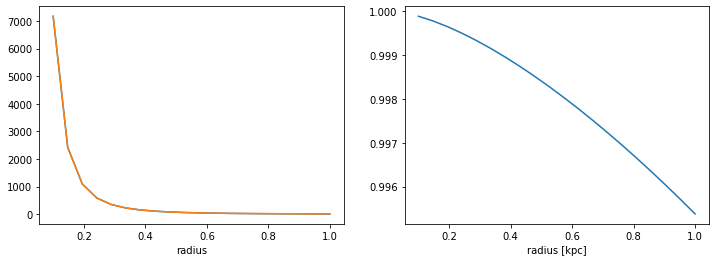

In [78]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(radius, dd_ana)
ax[0].plot(radius, dd_num); ax[0].set_xlabel("radius")
ax[1].plot(radius, np.array(dd_ana)/np.array(dd_num)); ax[1].set_xlabel("radius [kpc]")

# Second derivative temperature with respect to mass & age


\begin{equation}
\frac{\partial^2 T}{\partial A \partial M}
\end{equation} 

In [16]:
r=0.1; f=1.; params=[1., 20., 0.42]; v=100.; 
M=0.025; ages=np.linspace(1.1, 9.9, 60)

TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)

_ages, _c1 = np.genfromtxt(path + "dderv_ana_wrt_MA.dat", unpack=True)
c1_interp  = interp1d(_ages, _c1)

Text(0.5, 0, 'ages [Gyr]')

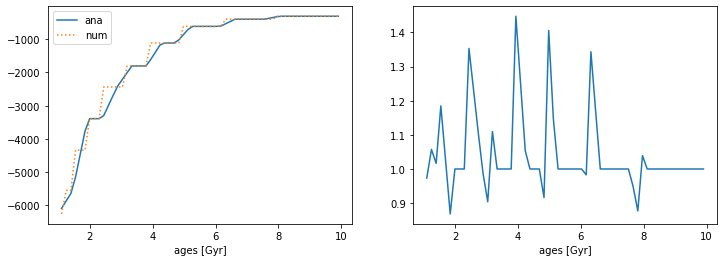

In [9]:
dd_num = []; dd_ana = []

_ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)                                                                 

for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(interp1d(_ages, c), A, dx=1e-6))
    dd_ana.append(c1_interp(A))
    
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ages, dd_ana, label="ana")
ax[0].plot(ages, dd_num, ls=":", label="num"); ax[0].set_xlabel("ages [Gyr]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(ages, dd_ana/dd_num); 
ax[1].set_xlabel("ages [Gyr]")    

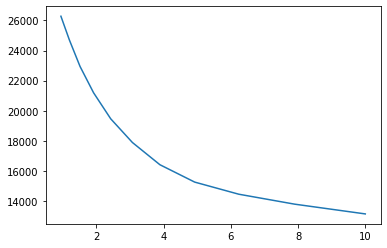

In [68]:
fig, ax = plt.subplots()
ax.plot(_ages, c_interp(_ages))

In [17]:
from derivatives import dderivativeT_wrt_MA, derivativeTDM_wrt_M


def dervT_M (A, r, f, params, M, v, c, TDM):
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    return ((Tint/Ttot)**3* c(A) + (TDM/Ttot)**3*derivativeTDM_wrt_M(r, f, params, M, v))

dd_num = []; #dd_ana = []

for A in ages:
    #xi   = np.transpose(np.asarray([A, M]))
    #Tint = griddata(points, values, xi)[0]
    #Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(dervT_M, A, args=(r, f, params, M, v, c_interp, TDM), dx=1e-6))
    
    #dd_ana.append(dderivativeT_wrt_MA(r, M, A, a_interp, b_interp, c_interp, 
    #                                  c1_interp, Tint, TDM, Ttot, f, params, v))


In [18]:
Tint = []
for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])
Tint = np.asarray(Tint)
Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
dd_ana = dderivativeT_wrt_MA(r, M, ages, a_interp, b_interp, c_interp, c1_interp, Tint, TDM, Ttot, f, params, v)

Text(0.5, 0, 'ages [Gyr]')

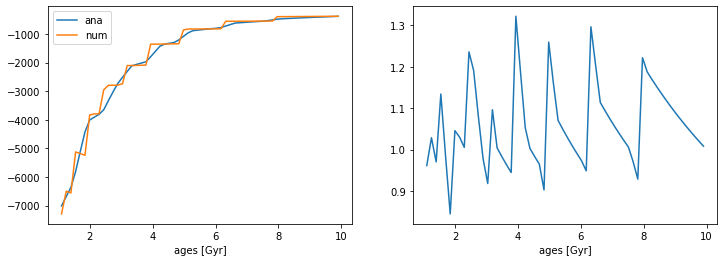

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ages, dd_ana, label="ana")
ax[0].plot(ages, dd_num, label="num"); ax[0].set_xlabel("ages [Gyr]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(ages, dd_ana/dd_num); ax[1].set_xlabel("ages [Gyr]")


\begin{equation}
\frac{\partial^2 T}{\partial M \partial A}
\end{equation}

In [40]:
r=0.1; f=1.; params=[1., 20., 0.42]; v=100.; 
masses = np.linspace(0.02, 0.045, 40); A=7.896523

In [41]:
!head /home/mariacst/exoplanets/running/data/dderv_ana_wrt_AM.dat

# Tint = a*masses + b
# da/dM = 25918.3 K/Gyr/Msun
# masses [Msun]  db/dM [K/Msun]
0.015000  5.150859
0.016000  5.150859
0.017000  4.826369
0.018000  3.777572
0.019000  3.317085
0.020000  3.394401
0.021000  3.618423


In [22]:
from derivatives import derivativeTintana_wrt_A, dderivativeTint_wrt_AM

dd_num = []
dd_ana = []

_masses, _b1 = np.genfromtxt(path + "dderv_ana_wrt_AM.dat", unpack=True)
b1_interp  = interp1d(_masses, _b1)

for M in masses:
    
    dd_num.append(derivative(derivativeTintana_wrt_A, M, args=(A, a_interp, b_interp), dx=1e-5))
    dd_ana.append(dderivativeTint_wrt_AM(M, A, a_interp, b_interp, b1_interp))

Text(0.5, 0, 'masses [Msun]')

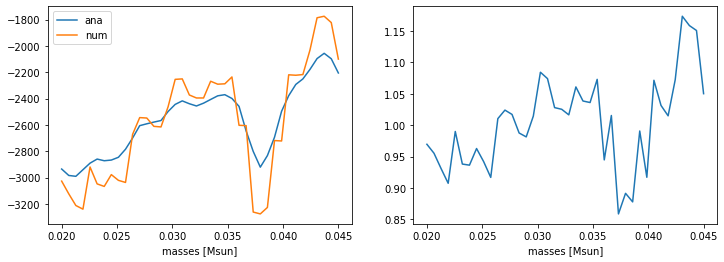

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(masses, dd_ana, label="ana")
ax[0].plot(masses, dd_num, label="num"); ax[0].set_xlabel("masses [Msun]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(masses, dd_ana/dd_num); ax[1].set_xlabel("masses [Msun]")

In [42]:
from derivatives import derivativeTintana_wrt_A, dderivativeT_wrt_AM

dd_num = []; #dd_ana = []

_masses, _b1 = np.genfromtxt(path + "dderv_ana_wrt_AM.dat", unpack=True)
b1_interp  = interp1d(_masses, _b1)


def dervT_wrt_A(M, A, a, b):
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    return (Tint/Ttot)**3*derivativeTintana_wrt_A(M, A, a, b)

for M in masses:  
    #xi   = np.transpose(np.asarray([A, M]))
    #Tint = griddata(points, values, xi)[0]
    #TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    #Ttot = np.power(Tint**4 + TDM**4, 0.25)    
    
    dd_num.append(derivative(dervT_wrt_A, M, args=(A, a_interp, b_interp), dx=1e-5))
    
    #dd_ana.append(dderivativeT_wrt_AM(r, M, A, a_interp, b_interp, b1_interp, c_interp, 
    #                                  Tint, TDM, Ttot, f, params, v))

In [43]:
Tint = []
for M in masses:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])
Tint = np.asarray(Tint)
TDM  = T_DM(r, M=masses*M_sun.value, f=f, params=params, v=v)
Ttot = np.power(Tint**4 + TDM**4, 0.25)

dd_ana = dderivativeT_wrt_AM(r, masses, A, a_interp, b_interp, b1_interp, c_interp, Tint, TDM, Ttot, f, params, v)

Text(0.5, 0, 'masses [Msun]')

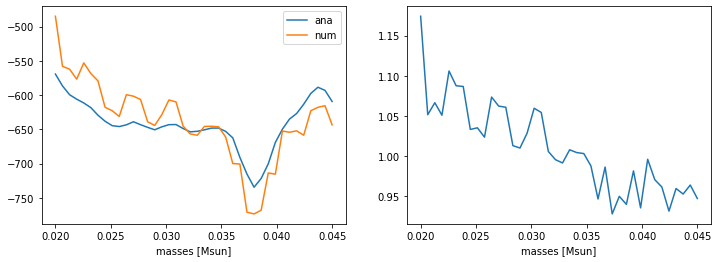

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(masses, dd_ana, label="ana")
ax[0].plot(masses, dd_num, label="num"); ax[0].set_xlabel("masses [Msun]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(masses, dd_ana/dd_num); ax[1].set_xlabel("masses [Msun]")

# Second derivative temperature with respect to radius & age

\begin{equation}
\frac{\partial^2 T}{\partial r \partial A} = 
\frac{\partial^2 T}{\partial A \partial r}
\end{equation}

I have checked also the equality!

In [46]:
r=0.1; f=1.; params=[1., 20., 0.42]; v=100.; 
M=0.035; ages=np.linspace(1.1, 9.9, 20)

TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)

In [47]:
from derivatives import derivativeTDM_wrt_r, derivativeTintana_wrt_A

def dderivativeT_wrt_rA(A, M, r, a, b, Tint, TDM, Ttot, f, params, v):             
    """                                                                            
    delta_{A, r}^2(temperature) = delta_{r, A}^2(temperature)                      
    """                                                                            
    # return                                                                       
    return (-3./Ttot*(TDM/Ttot)**3*derivativeTDM_wrt_r(r, f, params, M, v)*        
        (Tint/Ttot)**3*derivativeTintana_wrt_A(M, A, a, b))   

def dervT_wrt_rA(A, r, f, params, M, v, TDM):
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    Ttot = np.power(Tint**4+TDM**4, 0.25)
    return (TDM/Ttot)**3*derivativeTDM_wrt_r(r, f, params, M, v)

def dervT_wrt_Ar(r, A, f, params, M, v, Tint, a, b):
    TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    Ttot = np.power(Tint**4+TDM**4, 0.25)
    return (Tint/Ttot)**3*derivativeTintana_wrt_A(M, A, a, b)

In [48]:
dd_num_rA = []; dd_ana = []; dd_num_Ar = []

for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    
    dd_num_rA.append(derivative(dervT_wrt_rA, A, args=(r, f, params, M, v, TDM), dx=1e-5))
    
    dd_num_Ar.append(derivative(dervT_wrt_Ar, r, args=(A, f, params, M, v, Tint, a_interp, b_interp), dx=1e-6))
    
    #Ttot = np.power(Tint**4+TDM**4, 0.25)
    #dd_ana.append(dderivativeT_wrt_rA(A, M, r, a_interp, b_interp, Tint, TDM, Ttot, f, params, v))

In [49]:
Tint = []
for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])
Tint = np.asarray(Tint); Ttot = np.power(Tint**4+TDM**4, 0.25)

dd_ana = dderivativeT_wrt_rA(ages, M, r, a_interp, b_interp, Tint, TDM, Ttot, f, params, v)

Text(0.5, 0, 'ages [Gyr]')

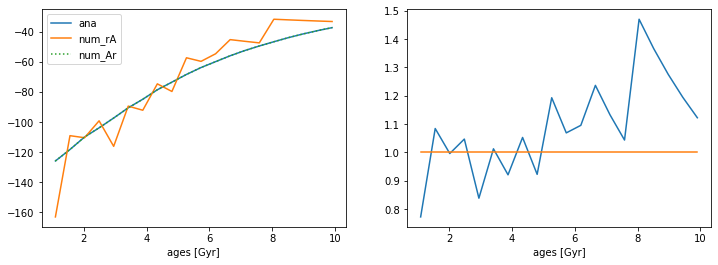

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ages, dd_ana, label="ana")
ax[0].plot(ages, dd_num_rA, label="num_rA"); ax[0].set_xlabel("ages [Gyr]")
ax[0].plot(ages, dd_num_Ar, ls=":", label="num_Ar"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(ages, dd_ana/dd_num_rA); ax[1].plot(ages, dd_ana/dd_num_Ar);
ax[1].set_xlabel("ages [Gyr]")

# Second derivative temperature with respect to radius & mass

<p style="color:red;">
\begin{equation}
\frac{\partial^2 T_{DM}}{\partial r \partial M}
\end{equation} ---> PROBLEM, primero, unidades. Segundo, parece que no casa!  
</p>

In [40]:
from astropy.constants import G, sigma_sb
import astropy.units as u
from utils import gNFW_rho
from derivatives import derivativeTDM_wrt_r

def dderivativeTDM_wrt_Mr(r, f, params, M, v, TDM,                                 
                          Rsun=8.178, epsilon=1):                                  
    """                                                                            
    delta_{r, M}^2(DM temperature)                                                 
    """                                                                            
    #TODO: Are the formula + conversion units correct?                          
    if v:                                                                          
        _vD = v*u.km/u.s                                                                    
    else:                                                                          
        _vD    = np.sqrt(3/2.)*vc(Rsun, r, params) # km/s                          
                                                                                   
    _vDM   =  np.sqrt(8./(3*np.pi))*_vD*u.km/u.s # km/s                                  
                                                                                   
    rhoDM  = gNFW_rho(Rsun, r, params)*u.GeV/u.cm**3 # GeV/cm3                                   
                                                                                   
    dervTDM_r   = derivativeTDM_wrt_r(r, f, params, M, v)*u.K/u.kpc                         
    dervRhoDM_r = -rhoDM*(params[0]/r + (3.-params[0]/(params[1]+r)))/u.kpc
    
    print(3./16.*G*f/(sigma_sb*epsilon)*np.sqrt(8./(3*np.pi))/_vD/TDM**3)
    print(rhoDM/r**2/u.kpc**2, 3./r*rhoDM/TDM*dervTDM_r/u.K/u.kpc, 1./r*dervRhoDM_r/u.kpc)
                                                   
    # return                                                                    
    return (3./16.*G*f/(sigma_sb*epsilon)*np.sqrt(8./(3*np.pi))/_vD/TDM**3*  
            (-rhoDM/r**2/u.kpc**2 - 3./r*rhoDM/TDM*dervTDM_r/u.K/u.kpc + 1./r*dervRhoDM_r/u.kpc)/u.K**3            
        )   

In [43]:
3./16.*G/sigma_sb/100

<Quantity 2.20696405e-06 K4 m5 / (kg s2 W)>

In [41]:
radius=np.linspace(0.1, 1., 20); f=1.; params=[1., 20., 0.42]; v=100.; 
M=0.035; A=4.5

TDM = T_DM(radius[2], M=M*M_sun.value, f=f, params=params, v=v)
dd_ana = dderivativeTDM_wrt_Mr(radius[2], f, params, M, v, TDM)

dd_ana

2.0539762769207217e-14 K4 m5 / (kg km s W)
905.5156494863226 GeV / (cm3 kpc2) -692.2345113183944 GeV / (cm3 kpc2) -1425.7955813271003 GeV / (cm3 kpc2)


<Quantity -3.3666247e-11 GeV K m5 / (cm3 kg km kpc2 s W)>

In [30]:
dd_ana.to(u.K/u.kpc/u.kg)*M_sun

<Quantity -3.4758455e-07 K / kpc>

In [31]:
print(dd_num[2])

-4112.752736000402


In [16]:
t = 1.*u.m**5*u.GeV*u.K/u.W/u.kg/u.km/u.s/u.kpc**2/u.cm**3
print(t.to(u.K/u.kpc/u.kg))

t = 1.*u.m**5*u.GeV*u.K/u.W/u.kg/u.km/u.s/u.kpc**2/u.cm**3
print(t.to(u.K/u.kpc/u.kg)*M_sun)

5.1923008534988834e-27 K / (kg kpc)
10324.422268731094 K / kpc


In [53]:
M_sun

<<class 'astropy.constants.iau2015.IAU2015'> name='Solar mass' value=1.988409870698051e+30 uncertainty=4.468805426856864e+25 unit='kg' reference='IAU 2015 Resolution B 3 + CODATA 2018'>

In [17]:
imp.reload(derivatives)
from derivatives import dderivativeTDM_wrt_Mr, derivativeTDM_wrt_M

radius=np.linspace(0.1, 1., 20); f=1.; params=[1., 20., 0.42]; v=100.; 
M=0.035; A=4.5

xi   = np.transpose(np.asarray([A, M]))
Tint = griddata(points, values, xi)[0]

-4871.776467664491


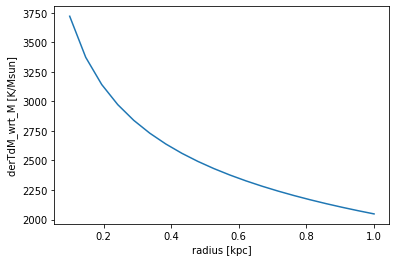

In [35]:
dervTDM_M = derivativeTDM_wrt_M(radius, f, params, M, v)
    
fig, ax = plt.subplots()
ax.plot(radius, dervTDM_M); ax.set_xlabel("radius [kpc]");
ax.set_ylabel("derTdM_wrt_M [K/Msun]")

print((dervTDM_M[2]-dervTDM_M[1])/(radius[2]-radius[1]))

In [18]:
dd_num = []
for r in radius:  
    dd_num.append(derivative(derivativeTDM_wrt_M, r, args=(f, params, M, v), dx=1e-5))    

In [19]:
TDM = T_DM(radius, M=M*M_sun.value, f=f, params=params, v=v)
dd_ana = dderivativeTDM_wrt_Mr(radius, f, params, M, v, TDM)

Text(0.5, 0, 'radius [kpc]')

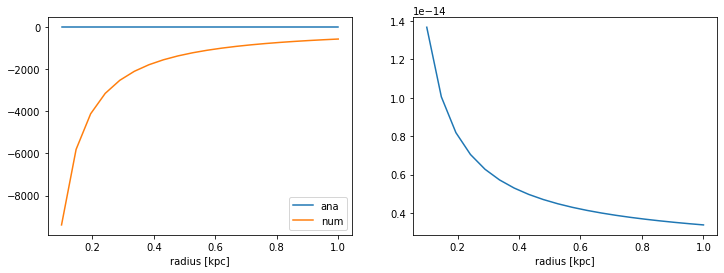

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(radius, dd_ana, label="ana")
ax[0].plot(radius, dd_num, label="num"); ax[0].set_xlabel("radius [kpc]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(radius, dd_ana/dd_num); ax[1].set_xlabel("radius [kpc]")

\begin{equation}
\frac{\partial^2 T}{\partial r \partial M}
\end{equation}

In [7]:
dd_num = []; #dd_ana = []

def dervT_M (r, A, f, params, M, v, c, Tint): 
    TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    return ((Tint/Ttot)**3* c(A) + (TDM/Ttot)**3*derivativeTDM_wrt_M(r, f, params, M, v))
    

for r in radius:  
    dd_num.append(derivative(dervT_M, r, args=(A, f, params, M, v, c_interp, Tint), dx=1e-5))
    
    #TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    #Ttot = np.power(Tint**4 + TDM**4, 0.25)
    #dd_ana.append(dderivativeT_wrt_Mr(r, M, A, c_interp, Tint, TDM, Ttot, f, params, v))

In [6]:
TDM = T_DM(radius, M=M*M_sun.value, f=f, params=params, v=v)
Ttot = np.power(Tint**4 + TDM**4, 0.25)

dd_ana = dderivativeT_wrt_Mr(radius, M, A, c_interp, Tint, TDM, Ttot, f, params, v)

Text(0.5, 0, 'radius [kpc]')

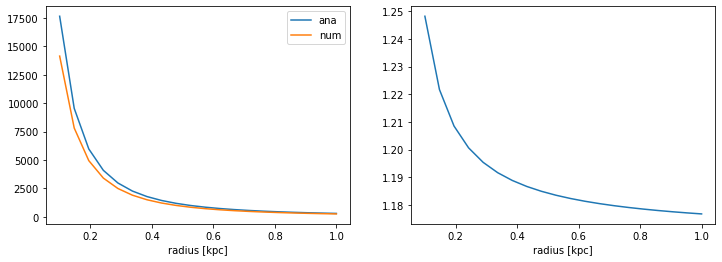

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(radius, dd_ana, label="ana")
ax[0].plot(radius, dd_num, label="num"); ax[0].set_xlabel("radius [kpc]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(radius, dd_ana/dd_num); ax[1].set_xlabel("radius [kpc]")